# Additional Pipeline Syntaxes

This notebooks introduces syntaxes to ease creation and manipulation of `Pipeline`objects:

- named pipelines,
- combination using `|` operation,
- reversing pipelines.

In [1]:
import numpy as np

def repr_ndarray(arr):
    return f"array(..., shape={arr.shape}, dtype={arr.dtype})"

np.set_printoptions(override_repr=repr_ndarray)

In [2]:
import pyearthtools.data
import pyearthtools.pipeline

To illustrate these features, we'll reuse the same pipeline as the one used in the [End-to-end CNN Training Example](../tutorial/CNN-Model-Training.ipynb).
Here is the original definition of the pipeline.

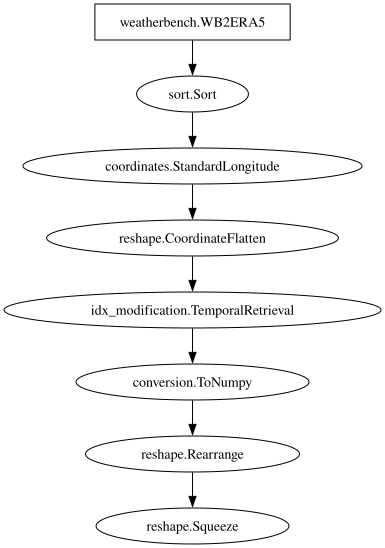

In [3]:
pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten(["level"]),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))
    ),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
)

## Named pipelines

When developing a new pipeline, it can be convenient to separate the main stages of a long pipeline into these sub-pipelines, and assemble them into one big pipeline afterwards.
However, once the pipeline has been assembled, we loose access to the sub-pipelines.
To solve this, we can add a **name** to each of the sub-pipelines.
Then, in the final pipeline, we can recover them via the `.named` attribute, which is a dictionary of all the named sub-pipelines contained in a pipeline.

In the following example, we build the same pipeline but split into 3 stages:
- a named pipeline "prepare", to fetch the data and apply few transformation on it,
- a temporal retrieval step, to generate the tuple of (features, target) samples,
- a named pipeline "reshape", to do the final convertion to numpy and reshaping.

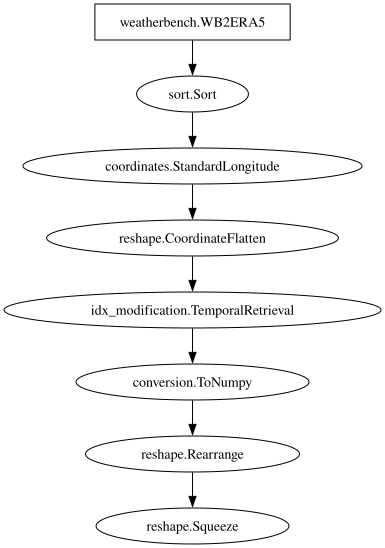

In [4]:
pipeline = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.Pipeline(
        pyearthtools.data.download.weatherbench.WB2ERA5(
            variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
            level=[850],
            license_ok=True,
        ),
        pyearthtools.pipeline.operations.xarray.Sort(
            ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
        ),
        pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
        pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten(["level"]),
        name="prepare"
    ),
    pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((0, 1), (6, 1))),
    pyearthtools.pipeline.Pipeline(
        pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
        pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
        pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
        name="reshape"
    ),
)
pipeline

We can inspect the `.named` attribute to see which named pipelines are accessible within a pipeline.

In [5]:
pipeline.named.keys()

dict_keys(['prepare', 'reshape'])

Then we can access the named pipeline "prepare" as follows.

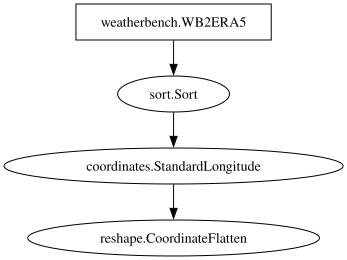

In [6]:
pipeline.named["prepare"]

And even use it without the rest of the pipeline, as it includes a data source.

In [7]:
pipeline.named["prepare"]["20210101T00"]

<xarray.Dataset> Size: 42kB
Dimensions:                 (latitude: 32, longitude: 64, time: 1)
Coordinates:
  * latitude                (latitude) float64 256B -87.19 -81.56 ... 87.19
  * longitude               (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * time                    (time) datetime64[ns] 8B 2021-01-01
Data variables:
    2m_temperature          (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    u_component_of_wind850  (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    v_component_of_wind850  (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    vorticity850            (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
    geopotential850         (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
Attributes:
    level-dtype:  int64

## Pipe operator

The `Pipeline` object also support the `|` operator (logical or) as a way to combine multiple pipelines together.
This has the same effect as creating a new `Pipeline` object as a combination of 2 pipelines (or a pipeline and a step).
This has not additional effect and can be used to increase the readability when building a long pipeline.

In the following example, we now create the sub-pipelines and the temporal retrieval step separately, as distinct objects, then combine them using the `|` operator.

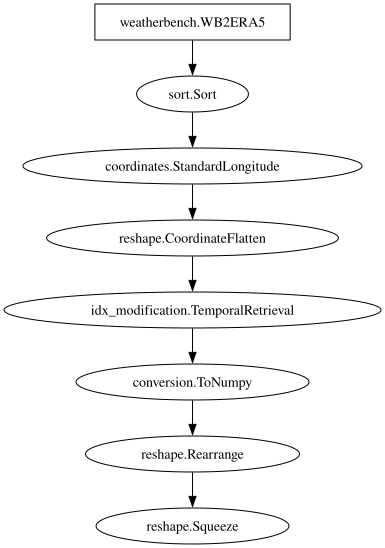

In [8]:
prepare = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten(["level"]),
    name="prepare"
)

retrieve = pyearthtools.pipeline.modifications.TemporalRetrieval(concat=True, samples=((0, 1), (6, 1)))

reshape = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
    name="reshape"
)

pipeline = prepare | retrieve | reshape
pipeline

In [9]:
pipeline["20210101T00"]

(array(..., shape=(5, 64, 32), dtype=float32),
 array(..., shape=(5, 64, 32), dtype=float32))

## Reversed pipeline

Pipelines can be reversed, i.e. undoing their effect.
The reverse of a pipeline can be obtained via the `.reversed` atttribute.

**Important:** Depending on the steps in a pipeline, some might have a proper "undo" method but others will just be skipped, i.e. will not apply any change to the sample while undoing the pipeline. In our example, it is the case of the `pyearthtools.data.download.weatherbench.WB2ERA5` and `pyearthtools.pipeline.modifications.TemporalRetrieval` steps.

In the following example, we'll reverse the "reshape" sub-pipeline, which is only made of reversible steps.

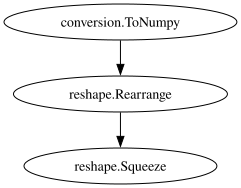

In [10]:
pipeline.named["reshape"]

In [11]:
pipeline.named["reshape"].reversed

ReversedPipeline
	Initialisation                 Operation reversing the effect of pipeline
		 forward_pipeline               {'Pipeline': {'__args': "(ToNumpy\n\tInitialisation                 Convert xarray objects to np.ndarray's\n\t\t reference_dataset              None\n\t\t run_parallel                   False\n\t\t saved_records                  None\n\t\t warn                           True, Rearrange\n\tInitialisation                 Operation to rearrange data using einops\n\t\t rearrange                      'c t h w -> t c h w'\n\t\t rearrange_kwargs               None\n\t\t reverse_rearrange              None\n\t\t skip                           False, Squeeze\n\tInitialisation                 Operation to Squeeze one-Dimensional axes at 'axis' location\n\t\t axis                           0)", 'exceptions_to_ignore': 'None', 'iterator': 'None', 'name': "'reshape'", 'sampler': 'None'}}

To test it, we'll fetch a sample from the "prepare" pipeline, reshape it and apply the reverse.

In [12]:
(prepare | reshape | reshape.reversed)["20210101T00"]

<xarray.Dataset> Size: 42kB
Dimensions:                 (time: 1, longitude: 64, latitude: 32)
Coordinates:
  * time                    (time) datetime64[ns] 8B 2021-01-01
  * longitude               (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                (latitude) float64 256B -87.19 -81.56 ... 87.19
Data variables:
    2m_temperature          (time, longitude, latitude) float32 8kB 241.9 ......
    u_component_of_wind850  (time, longitude, latitude) float32 8kB -3.03 ......
    v_component_of_wind850  (time, longitude, latitude) float32 8kB -0.7963 ....
    vorticity850            (time, longitude, latitude) float32 8kB -1.147e-0...
    geopotential850         (time, longitude, latitude) float32 8kB 1.117e+04...
Attributes:
    level-dtype:  int64

### End-to-end inference pipeline example

Now, let's imagine one of our steps is an inference from a model, returning a numpy array.
To create an end-to-end pipeline, generating xarray samples in the same space as the original data source, we will reverse the whole preparation pipeline and add it at the end.
Note that in the reversed pipeline, the `pyearthtools.data.download.weatherbench.WB2ERA5` and `pyearthtools.pipeline.modifications.TemporalRetrieval` steps do not apply any effect on the sample being transformed, being effectively skipped.

For illustration purpose, we will use a simple persistence model, that return the last sample from the tuple generated via `pyearthtools.pipeline.modifications.TemporalRetrieval`.

In [13]:
from pyearthtools.pipeline.step import PipelineStep

class Persistence(PipelineStep):
    def __init__(self):
        super().__init__()
        self.record_initialisation()
    def run(self, sample):
        return sample[-1]

persistence = Persistence()

We can run create an inference pipeline by adding it at the end of our preprocessing pipeline.
Unfortunately, this returns a numpy array sample when queried, missing all the information about variable names and coordinates.

In [14]:
(pipeline | persistence)["20210101T00"]

array(..., shape=(5, 64, 32), dtype=float32)

To get a real end-to-end pipeline, we just need to add the preprocessing pipeline reversed.

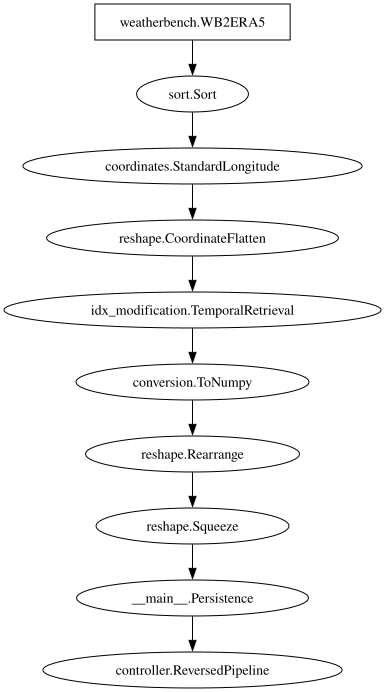

In [15]:
end_to_end = pipeline | persistence | pipeline.reversed
end_to_end

In [16]:
end_to_end["20210101T00"]

<xarray.Dataset> Size: 42kB
Dimensions:              (time: 1, longitude: 64, latitude: 32, level: 1)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2021-01-01
  * longitude            (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude             (latitude) float64 256B -87.19 -81.56 ... 81.56 87.19
  * level                (level) float64 8B 850.0
Data variables:
    2m_temperature       (time, longitude, latitude) float32 8kB 241.8 ... 260.0
    u_component_of_wind  (time, longitude, latitude) float32 8kB -2.618 ... -...
    v_component_of_wind  (time, longitude, latitude) float32 8kB -2.405 ... 1...
    vorticity            (time, longitude, latitude) float32 8kB -1.714e-05 ....
    geopotential         (time, longitude, latitude) float32 8kB 1.12e+04 ......

Note that our simple model doesn't handle the time information, so we would need to fix the time information of the sample, for example adding 6 hours to the `time` coordinate if we are forecasting at T+6H.